In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import scipy.stats as stats

import statsmodels
import statsmodels.api as sm

import shap

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, r2_score

import xgboost as xgb

c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_full_data = pd.read_csv('train.csv')

In [3]:
train_full_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train_full_data["Heart Disease"].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

https://www.kaggle.com/datasets/neurocipher/heartdisease/data

Categorical variables:
1. Sex
2. Chest pain type -> [1, 2, 3, 4]
3. FBS over 120 -> [
    0 = False
    1 = True
]
4. EKG results -> [
    ❤️ 0 = Normal
    ⚠️ 1 = ST-T wave abnormality
    💥 2 = Left ventricular hypertrophy
]
5. Exercise angina
6. Slope of ST
6. Thallium
7. Heart Disease (target variable)  

Numerical variables:
1. BP
2. Cholesterol
3. Max HR
4. ST depression

Confusion:
1. Age
2. Number of vessels fluro

In this case, we will use these confused variables as both numerical and categorical variables and check which one is a better predictor of heart disease.

In [5]:
train_full_data.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [6]:
train_full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [7]:

train_full_data["y"] = train_full_data["Heart Disease"].map({"Absence": 0, "Presence": 1})

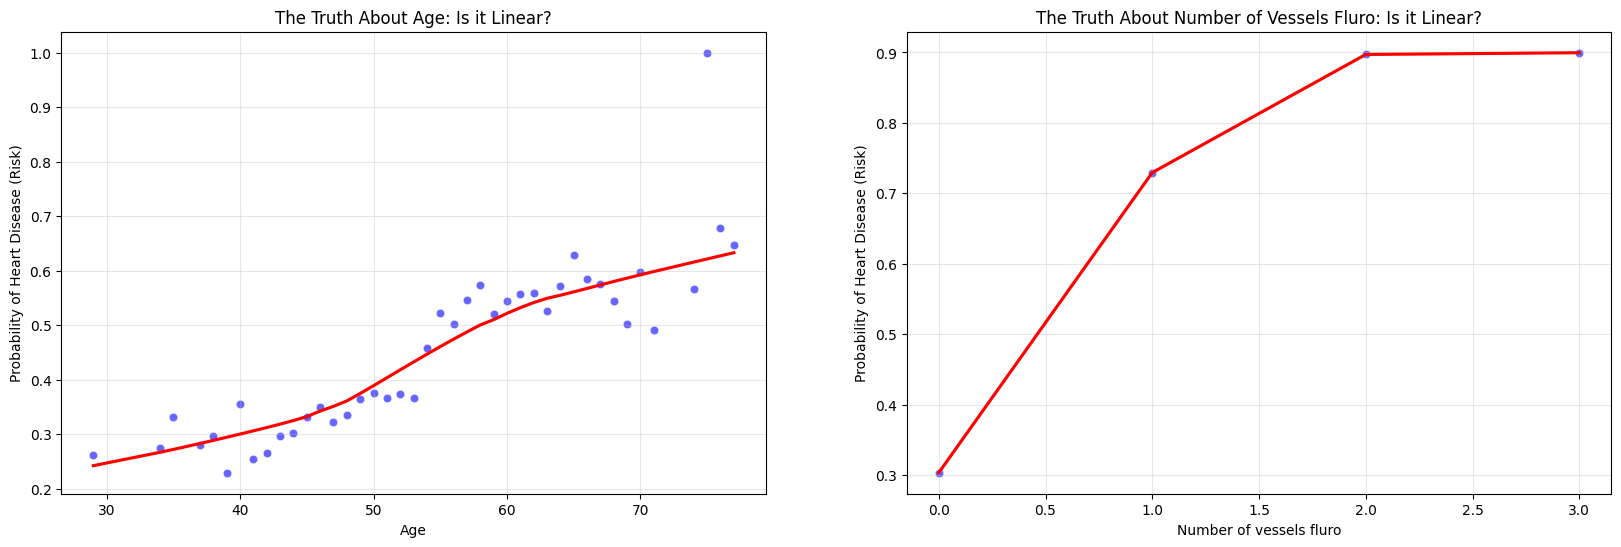

In [8]:
# 1. Calculate the Probability of Heart Disease for each Age
age_risk = train_full_data.groupby('Age')['y'].mean()
vessel_risk = train_full_data.groupby('Number of vessels fluro')['y'].mean()

# 2. Plot it
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
sns.scatterplot(x=age_risk.index, y=age_risk.values, color='blue', alpha=0.6, ax=ax[0])
sns.regplot(x=age_risk.index, y=age_risk.values, scatter=False, color='red', lowess=True, ax=ax[0])

ax[0].set_title("The Truth About Age: Is it Linear?")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Probability of Heart Disease (Risk)")
ax[0].grid(True, alpha=0.3)


sns.scatterplot(x=vessel_risk.index, y=vessel_risk.values, color='blue', alpha=0.6, ax=ax[1])
sns.regplot(x=vessel_risk.index, y=vessel_risk.values, scatter=False, color='red', lowess=True, ax=ax[1])

ax[1].set_title("The Truth About Number of Vessels Fluro: Is it Linear?")
ax[1].set_xlabel("Number of vessels fluro")
ax[1].set_ylabel("Probability of Heart Disease (Risk)")
ax[1].grid(True, alpha=0.3)

plt.show()

This shows that Age and Number of vessels fluro are both numerical variables as the probability of heart disease increases with age and number of vessels fluro. 

However, we will also check the categorical versions of these variables to see if they provide any additional insights.

# Statistical inference

Univariate analysis:
1. Check the distribution of the target variable (Heart Disease) and the categorical variables.
2. Check the distribution of the numerical variables using violin plots.
3. Check the statistical significance by looking at the logistic regression summary.

## Y-variable analysis

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

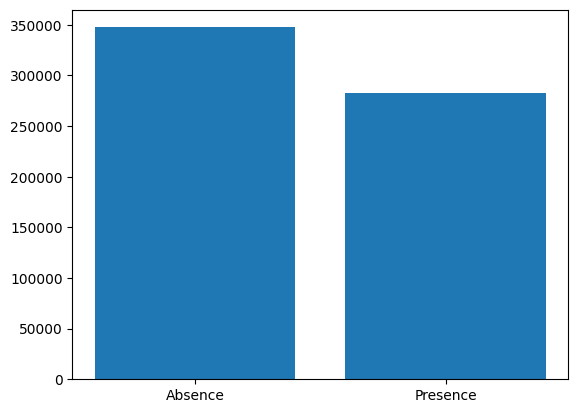

In [9]:
heart_data = train_full_data["Heart Disease"].value_counts()
plt.bar(heart_data.index, heart_data.values)
heart_data

## Missing values

In [10]:
train_full_data.isnull().sum().sum()

np.int64(0)

## Examine numerical variables

In [11]:
numerical_columns = [
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression",
    # These may be numerical or categorical. Need to verify.
    "Age",
    "Number of vessels fluro"
]

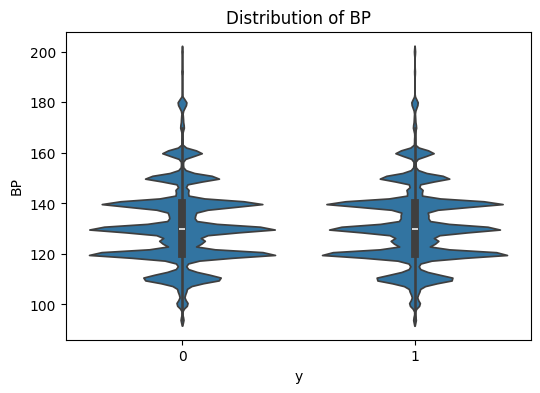

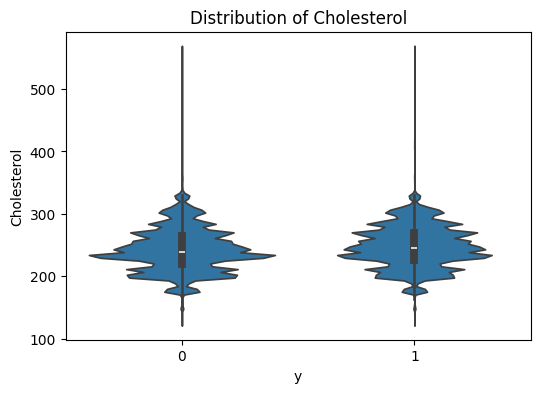

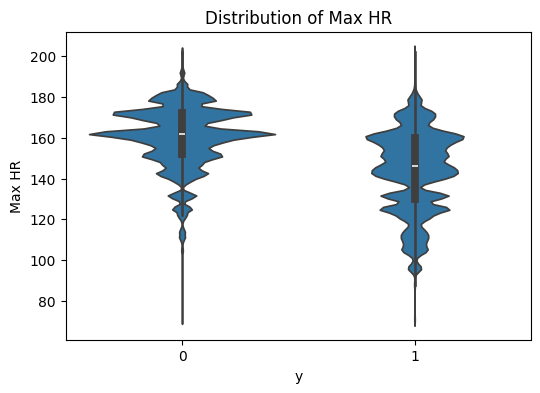

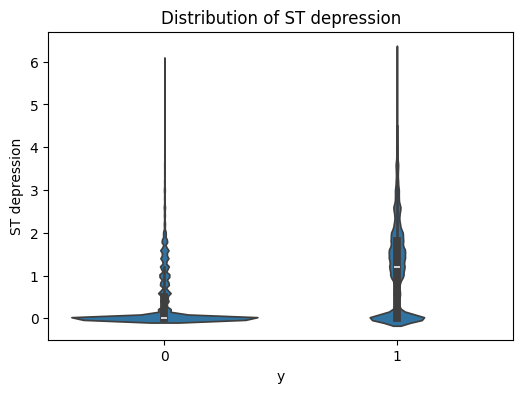

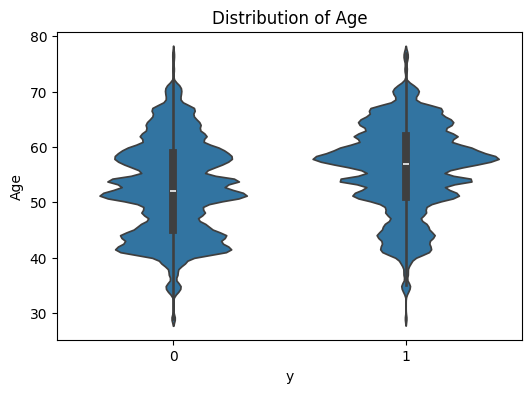

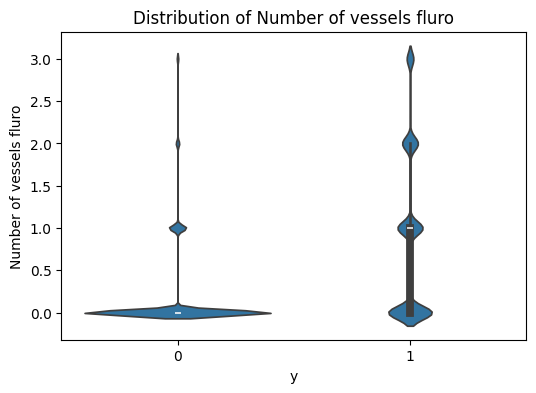

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=train_full_data, x="y", y=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel("y")
    plt.ylabel(col)
    plt.show()

From this diagram, we can observe that BP and Cholesterol do not have a significant difference in distribution between the two groups (y=0 and y=1) but it is always better to check the statistical significance of the difference in means of the two groups using a t-test. 


### Baseline model using "Number of vessels fluro" variable 
Just by looking at the data, it seems that the "Number of vessels fluro" variable is a strong predictor of heart disease. We can create a simple baseline model that predicts heart disease based on whether the "Number of vessels fluro" is greater than 0 or not.

In [13]:
check_pred = train_full_data['Number of vessels fluro'] != 0
print("Accuracy:", accuracy_score(train_full_data['y'], check_pred))
print("Precision:", precision_score(train_full_data['y'], check_pred))
print("Recall:", recall_score(train_full_data['y'], check_pred))
print("F1 Score:", f1_score(train_full_data['y'], check_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], check_pred))

Accuracy: 0.7269936507936507
Precision: 0.7999380899108277
Recall: 0.5214973057559815
F1 Score: 0.6313824497633908
ROC AUC Score: 0.707749913142819


Not needed to do t-test here but we can do it just to confirm our observation from the violin plot. We can check whether the means of the two groups (y=0 and y=1) are statistically different from each other or not. 

Why not to do t-test?

Observe the t-test null hypothesis: $H_0: \mu_1 = \mu_2$ where $\mu_1$ and $\mu_2$ are the means of the two groups (y=0 and y=1). But in this case, we are not interested in the means of the two groups. The t-test is not designed to check the difference in distribution between two groups but rather to check the difference in means. Therefore, it is not appropriate to use a t-test in this case. 

To find whether the distributions of 2 groups are identical, we can use a non-parametric test like the Mann-Whitney U test which is designed to check the difference in distribution between two groups.

But we are not interested in just checking the difference in distribution but also in checking the statistical significance of the difference in distribution while controlling for other variables. This is where logistic regression comes in. Logistic regression can handle multiple categorical variables and can give us the statistical significance of each variable while controlling for the other variables in the model.

In [14]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

# T-test null hypothesis: The means of the two groups are equal (no difference between groups) i.e mu_1 = mu_2.
# T-test alternative hypothesis: The means of the two groups are not equal (there is a difference between groups).

# Why t-test? We need to check whether the Population means of the two groups (y=0 and y=1) are 
# statistically different from each other or not. If they are statistically different, then we can say that 
# the variable is a good predictor of heart disease.
curr_d = []
for col in numerical_columns:
    d = {}
    y_is_0 = train_full_data[train_full_data["y"] == 0][col]
    y_is_1 = train_full_data[train_full_data["y"] == 1][col]
    f_stat, p_value = stats.ttest_ind(
        y_is_0,
        y_is_1,
        equal_var=False,  # Welch's t-test, does not assume equal population variance
        alternative='two-sided'  # two-tailed test
    )
    # A p-value larger than a chosen threshold (e.g. 5% or 1%) indicates 
    # that our observation is not so unlikely to have occurred by chance. 
    # Therefore, we do not reject the null hypothesis of equal population means.
    # => p_value > 0.05, means that observation is occurred by chance.
    d["Column"] = col
    d["F-statistic"] = f_stat
    d["P-value"] = p_value
    if p_value < 0.05:
        print(f"{col} is statistically significant with p-value: {p_value} and f-statistic: {f_stat}")
        mean_diff = y_is_0.mean() - y_is_1.mean()
        d["Mean Difference"] = mean_diff
        d["Cohen's d"] = abs(mean_diff / np.sqrt(((y_is_0.count() - 1) * y_is_0.var() + (y_is_1.count() - 1) * y_is_1.var())/(y_is_0.count() + y_is_1.count() - 2)))
    else:
        print(f"{col} is NOT statistically significant with p-value: {p_value}")
    curr_d.append(d)
results = pd.DataFrame(curr_d)
results.sort_values(by="Cohen's d", ascending=False, inplace=True)
results

BP is statistically significant with p-value: 3.7470104117314534e-05 and f-statistic: 4.122580558985724
Cholesterol is statistically significant with p-value: 0.0 and f-statistic: -66.14459965107095
Max HR is statistically significant with p-value: 0.0 and f-statistic: 378.7389740553235
ST depression is statistically significant with p-value: 0.0 and f-statistic: -360.5056053204741
Age is statistically significant with p-value: 0.0 and f-statistic: -173.4494773542856
Number of vessels fluro is statistically significant with p-value: 0.0 and f-statistic: -361.8669152526268


,Column,F-statistic,P-value,Mean Difference,Cohen's d
2,Max HR,378.738974,0.000000,16.947733,0.987968
5,Number of vessels fluro,-361.866915,0.000000,-0.704261,0.981356
3,ST depression,-360.505605,0.000000,-0.821296,0.959437
4,Age,-173.449477,0.000000,-3.521021,0.436392
1,Cholesterol,-66.144600,0.000000,-5.604483,0.166969
0,BP,4.122581,0.000037,0.156015,0.010418


### Baseline model using "ST depression" variable

Just by looking at the data, it seems that the "ST depression" variable is a strong predictor of heart disease. We can create a simple baseline model that predicts heart disease based on whether the "ST depression" is greater than 0 or not.

In [15]:
check_pred = train_full_data['ST depression'] != 0
print("Accuracy:", accuracy_score(train_full_data['y'], check_pred))
print("Precision:", precision_score(train_full_data['y'], check_pred))
print("Recall:", recall_score(train_full_data['y'], check_pred))
print("F1 Score:", f1_score(train_full_data['y'], check_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], check_pred))

Accuracy: 0.678963492063492
Precision: 0.6272785270154033
Recall: 0.6996926933235146
F1 Score: 0.6615097528932328
ROC AUC Score: 0.6809046813857939


### Multivariate analysis of numerical variables for statistical significance

In [16]:
train_full_data[numerical_columns + ["y"]].corr()   

,BP,Cholesterol,Max HR,ST depression,Age,Number of vessels fluro,y
BP,1.000000,-0.004597,0.004391,-0.004024,-0.003960,-0.003143,-0.005181
Cholesterol,-0.004597,1.000000,-0.048575,0.044678,0.019485,0.048800,0.082753
Max HR,0.004391,-0.048575,1.000000,-0.229462,-0.097542,-0.236319,-0.440985
ST depression,-0.004024,0.044678,-0.229462,1.000000,0.103064,0.293642,0.430641
Age,-0.003960,0.019485,-0.097542,0.103064,1.000000,0.102758,0.212091
Number of vessels fluro,-0.003143,0.048800,-0.236319,0.293642,0.102758,1.000000,0.438604
y,-0.005181,0.082753,-0.440985,0.430641,0.212091,0.438604,1.000000


We can observe that ST depression is correlating w.r.t Max HR and Number of vessels fluro but the correlation is not very strong. If the correlation was very strong like 0.8 or above, then we would have to be careful about multicollinearity when we include these variables in a logistic regression model to predict heart disease.

We can observe that Max HR, Number of vessels fluro, ST depression, Age and Cholesterol are statistically significant predictors of heart disease. We can check the statistical significance of these variables by looking at the logistic regression summary to predict the target variable and see which one is a better predictor of heart disease.

In [17]:
statsmodels.discrete.discrete_model.Logit(
    train_full_data['y'], 
    sm.add_constant(train_full_data[numerical_columns])
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.438073
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629993
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.3631
Time:                        16:10:38   Log-Likelihood:            -2.7599e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       2.8156      0.054     52.324      0.000       2.710       2.921
BP                         -0.0003      0.000     -1.145      0.252      -0.001       0.000
Cholesterol                 0.0039   9.95e-05     39.540      0.000       0.004       0.004
Max HR                     -0.0510      0.000   -247.675      0.000      -0.051      -0.051
ST depression               0.9274      0.004    223.274      0.000       0.919       0.936
Age                         0.0502      0.000    120.159      0.000       0.049       0.051
Number of vessels fluro     1.2438      0.006    220.787      0.000       1.233       1.255
===========================================================================================
"""

We can observe that 
1. Max HR, Number of vessels fluro, ST depression, Age, constant and cholesterol are statistically significant predictors of heart disease in decreasing order of importance.
2. BP failed the Wald's test.

In [18]:
poly_degree_2 = PolynomialFeatures(degree=2, include_bias=True)

train_num_poly_2 = poly_degree_2.fit_transform(train_full_data[numerical_columns])
train_num_poly_2 = pd.DataFrame(train_num_poly_2, columns=poly_degree_2.get_feature_names_out(numerical_columns)) 

statsmodels.discrete.discrete_model.Logit(
    train_full_data['y'],
    train_num_poly_2
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.434438
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629972
Method:                           MLE   Df Model:                           27
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.3684
Time:                        16:10:41   Log-Likelihood:            -2.7370e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
1                                        -5.9311      0.614     -9.665      0.000      -7.134      -4.728
BP                                        0.0169      0.004      4.226      0.000       0.009       0.025
Cholesterol                               0.0267      0.002     14.688      0.000       0.023       0.030
Max HR                                   -0.0126      0.004     -3.337      0.001      -0.020      -0.005
ST depression                             1.2644      0.067     18.928      0.000       1.134       1.395
Age                                       0.1208      0.008     15.809      0.000       0.106       0.136
Number of vessels fluro                   2.2030      0.086     25.679      0.000       2.035       2.371
BP^2                                  -4.812e-05   9.49e-06     -5.071      0.000   -6.67e-05   -2.95e-05
BP Cholesterol                        -3.096e-06   6.78e-06     -0.456      0.648   -1.64e-05    1.02e-05
BP Max HR                             -1.508e-05   1.38e-05     -1.092      0.275   -4.21e-05     1.2e-05
BP ST depression                         -0.0002      0.000     -0.766      0.444      -0.001       0.000
BP Age                                -1.656e-05   2.83e-05     -0.586      0.558    -7.2e-05    3.89e-05
BP Number of vessels fluro            -1.852e-05      0.000     -0.053      0.957      -0.001       0.001
Cholesterol^2                         -4.783e-05   2.22e-06    -21.580      0.000   -5.22e-05   -4.35e-05
Cholesterol Max HR                     2.039e-06   6.15e-06      0.332      0.740      -1e-05    1.41e-05
Cholesterol ST depression                 0.0002      0.000      1.523      0.128   -5.32e-05       0.000
Cholesterol Age                         1.85e-05   1.27e-05      1.459      0.144   -6.34e-06    4.33e-05
Cholesterol Number of vessels fluro       0.0003      0.000      1.803      0.071   -2.43e-05       0.001
Max HR^2                                 -0.0001   9.16e-06    -13.185      0.000      -0.000      -0.000
Max HR ST depression                     -0.0008      0.000     -3.020      0.003      -0.001      -0.000
Max HR Age                            -7.298e-06   2.56e-05     -0.285      0.776   -5.75e-05    4.29e-05
Max HR Number of vessels fluro           -0.0017      0.000     -5.183      0.000      -0.002      -0.001
ST depression^2                          -0.0827      0.004    -21.455      0.000      -0.090      -0.075
ST depression Age                        -0.0009      0.001     -1.726      0.084      -0.002       0.000
ST depression Number of vessels fluro    -0.0072      0.006     -1.169      0.242      -0.019       0.005
Age^2                                    -0.0007   4.38e-05    -15.035      0.000      -0.001      -0.001
Age Number of vessels fluro              -0.0014      0.001     -2.268      0.023      -0.003      -0.000
Number of vessels fluro^2                -0.3441      0.006  

Here, with polynomial features, there is a small increase in the Psuedo R-sqaure, implying that there is no need to include polynomial features in the model.

### Test with logistic regression model

In [19]:
lr_inference_num = LogisticRegression()
req_num_columns = list(set(numerical_columns) - {'BP'})
lr_inference_num.fit(train_full_data[req_num_columns], train_full_data['y'])
lr_inference_num_pred = lr_inference_num.predict(train_full_data[req_num_columns])
print("Accuracy:", accuracy_score(train_full_data['y'], lr_inference_num_pred))
print("Precision:", precision_score(train_full_data['y'], lr_inference_num_pred))
print("Recall:", recall_score(train_full_data['y'], lr_inference_num_pred))
print("F1 Score:", f1_score(train_full_data['y'], lr_inference_num_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], lr_inference_num_pred))

Accuracy: 0.8008142857142857
Precision: 0.8113374457028383
Recall: 0.7241037478669093
F1 Score: 0.7652425735072651
ROC AUC Score: 0.7936307152954614


## Examine categorical variables

In [20]:
categorical_variables = [
    "Sex", 
    "Chest pain type", 
    "FBS over 120", 
    "EKG results",
    "Exercise angina", 
    "Slope of ST", 
    "Thallium",
    # Confusion about whether these are numerical or categoric, Need "to verify.
]

confusion_variables = [
    "Age", 
    "Number of vessels fluro"
]

### Univariate analysis of categorical variables

In [21]:
for col in categorical_variables:
    train_full_data[col] = train_full_data[col].astype('category')

for col in confusion_variables:
    train_full_data[f"{col}_category"] = train_full_data[col].astype('category')

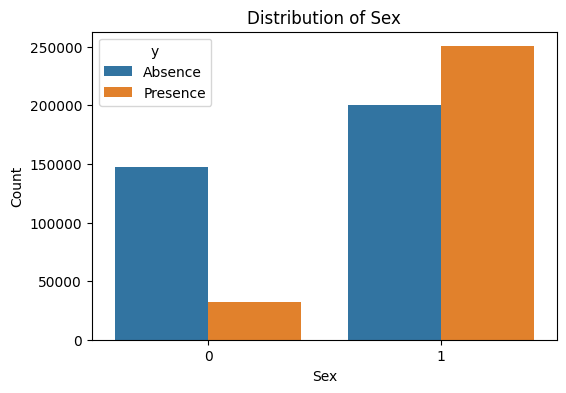

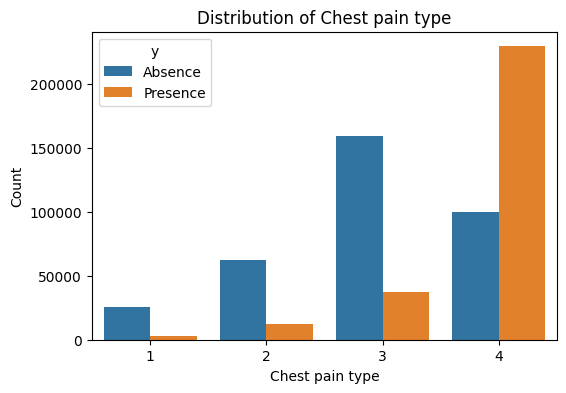

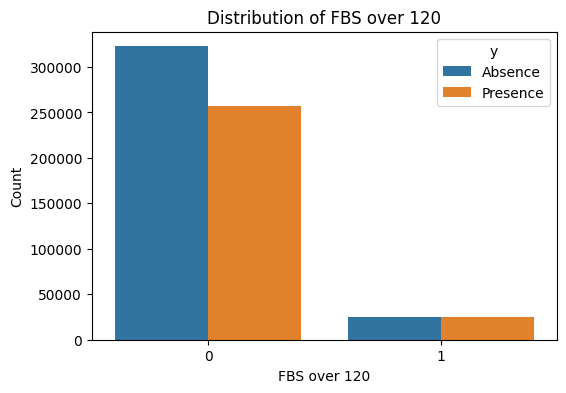

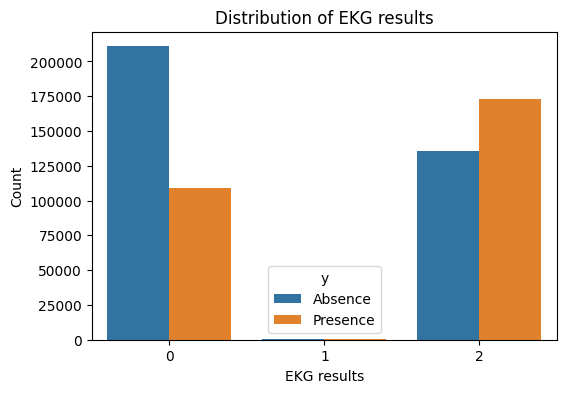

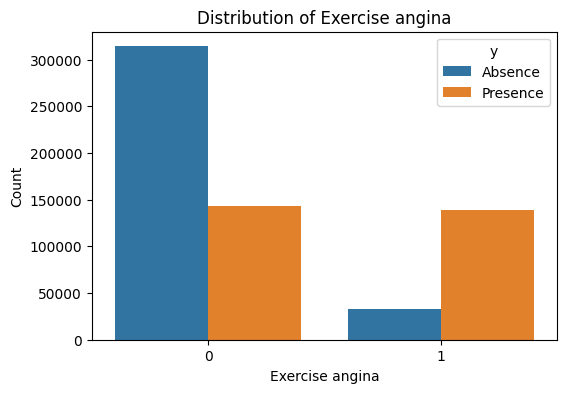

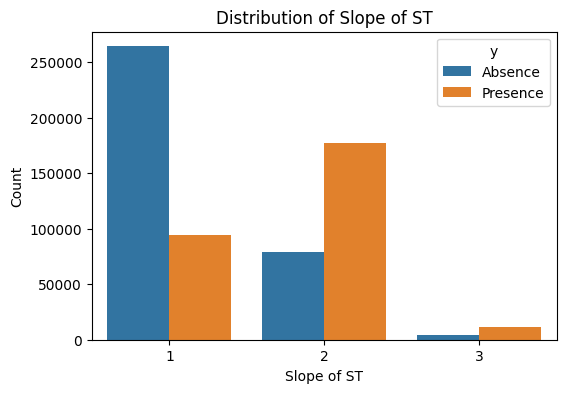

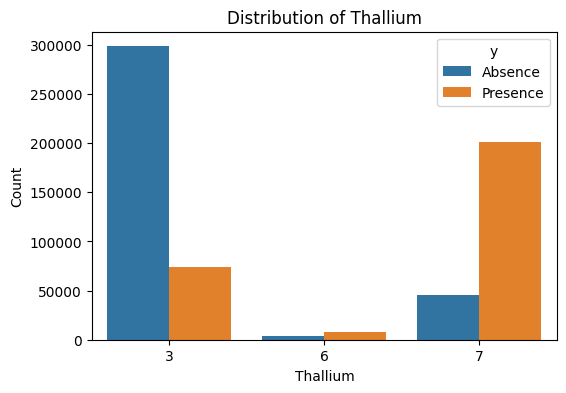

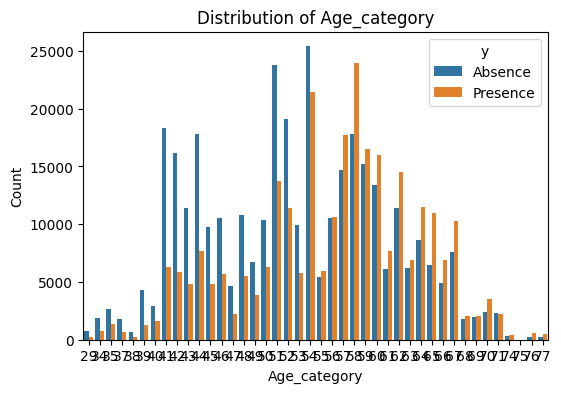

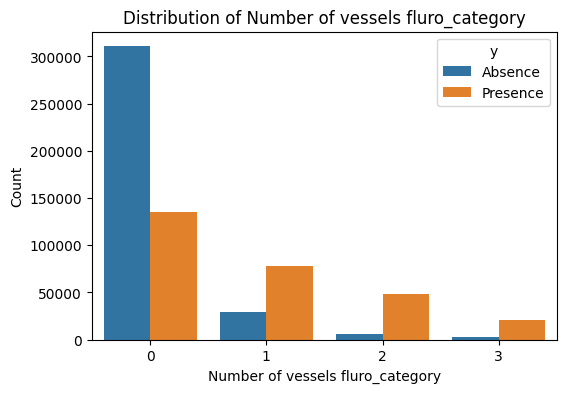

In [22]:
for col in categorical_variables + [f"{col}_category" for col in confusion_variables]:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=train_full_data, x=col, hue="y")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="y", labels=["Absence", "Presence"])
    plt.show()

### Multivariate analysis of numerical variables for statistical significance

Why I am not doing the Chi-square test for categorical variables? 

Because Chi-square test is used to check the association between two categorical variables feature $X$ and target $Y$ to tell about $P(X|Y)$ and $P(Y|X)$. But what about $P(Y|X, Z)$ where $Z$ is another categorical variable? This is where logistic regression comes in. Logistic regression can handle multiple categorical variables and can give us the statistical significance of each variable while controlling for the other variables in the model.


In [23]:
ohc_cat = OneHotEncoder(drop='first', sparse_output=False)
train_cat_data = ohc_cat.fit_transform(train_full_data[categorical_variables + [f"{col}_category" for col in confusion_variables]])
train_cat_data = pd.DataFrame(train_cat_data, columns=ohc_cat.get_feature_names_out())
train_cat_data

,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,...,Age_category_69,Age_category_70,Age_category_71,Age_category_74,Age_category_75,Age_category_76,Age_category_77,Number of vessels fluro_category_1,Number of vessels fluro_category_2,Number of vessels fluro_category_3
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
629996,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
629997,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
629998,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


```python
statsmodels.discrete.discrete_model.Logit(
    train_full_data['y'], 
    sm.add_constant(train_cat_data)
).fit().summary()
```

```shell
c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
Warning: Maximum number of iterations has been exceeded.
         Current function value: inf
         Iterations: 35

---------------------------------------------------------------------------
LinAlgError                               Traceback (most recent call last)
Cell In[23], line 4
      1 statsmodels.discrete.discrete_model.Logit(
      2     train_full_data['y'], 
      3     sm.add_constant(train_cat_data)
----> 4 ).fit().summary()

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2601, in Logit.fit(self, start_params, method, maxiter, full_output, disp, callback, **kwargs)
   2598 @Appender(DiscreteModel.fit.__doc__)
   2599 def fit(self, start_params=None, method='newton', maxiter=35,
   2600         full_output=1, disp=1, callback=None, **kwargs):
-> 2601     bnryfit = super().fit(start_params=start_params,
   2602                           method=method,
   2603                           maxiter=maxiter,
   2604                           full_output=full_output,
   2605                           disp=disp,
   2606                           callback=callback,
   2607                           **kwargs)
   2609     discretefit = LogitResults(self, bnryfit)
   2610     return BinaryResultsWrapper(discretefit)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:243, in DiscreteModel.fit(self, start_params, method, maxiter, full_output, disp, callback, **kwargs)
    240 else:
    241     pass  # TODO: make a function factory to have multiple call-backs
--> 243 mlefit = super().fit(start_params=start_params,
    244                      method=method,
    245                      maxiter=maxiter,
    246                      full_output=full_output,
    247                      disp=disp,
    248                      callback=callback,
    249                      **kwargs)
    251 return mlefit

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\base\model.py:582, in LikelihoodModel.fit(self, start_params, method, maxiter, full_output, disp, fargs, callback, retall, skip_hessian, **kwargs)
    580     Hinv = cov_params_func(self, xopt, retvals)
    581 elif method == 'newton' and full_output:
--> 582     Hinv = np.linalg.inv(-retvals['Hessian']) / nobs
    583 elif not skip_hessian:
    584     H = -1 * self.hessian(xopt)

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\numpy\linalg\_linalg.py:669, in inv(a)
    666 signature = 'D->D' if isComplexType(t) else 'd->d'
    667 with errstate(call=_raise_linalgerror_singular, invalid='call',
    668               over='ignore', divide='ignore', under='ignore'):
--> 669     ainv = _umath_linalg.inv(a, signature=signature)
    670 return wrap(ainv.astype(result_t, copy=False))

File c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\numpy\linalg\_linalg.py:163, in _raise_linalgerror_singular(err, flag)
    162 def _raise_linalgerror_singular(err, flag):
--> 163     raise LinAlgError("Singular matrix")

LinAlgError: Singular matrix
```

This implies that there is multi-collinearity between categorical variables.

In [24]:
for col in train_cat_data.columns:
    if col.startswith("Age_category_75"):
        print(f"--- {col} Check ---")
        print(pd.crosstab(train_cat_data[col], train_full_data['y']))
        print("\n")

--- Age_category_75 Check ---
y                     0       1
Age_category_75                
0.0              347546  282453
1.0                   0       1




Since age is creating issues because we considered as category, I am removing the age.

In [25]:
ohc_cat = OneHotEncoder(drop='first', sparse_output=False)
train_cat_data = ohc_cat.fit_transform(train_full_data[categorical_variables + [f"Number of vessels fluro_category"]])
train_cat_data = pd.DataFrame(train_cat_data, columns=ohc_cat.get_feature_names_out())
train_cat_data

,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7,Number of vessels fluro_category_1,Number of vessels fluro_category_2,Number of vessels fluro_category_3
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
629996,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
629997,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
629998,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [26]:
statsmodels.discrete.discrete_model.Logit(
    train_full_data['y'], 
    sm.add_constant(train_cat_data)
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.313985
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629984
Method:                           MLE   Df Model:                           15
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.5435
Time:                        16:10:55   Log-Likelihood:            -1.9781e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -5.0097      0.027   -186.657      0.000      -5.062      -4.957
Sex_1                                  1.1361      0.010    114.842      0.000       1.117       1.155
Chest pain type_2                      0.4725      0.028     17.104      0.000       0.418       0.527
Chest pain type_3                      0.5974      0.026     23.401      0.000       0.547       0.647
Chest pain type_4                      2.3358      0.025     93.687      0.000       2.287       2.385
FBS over 120_1                        -0.0038      0.015     -0.254      0.800      -0.033       0.026
EKG results_1                         -0.1214      0.092     -1.326      0.185      -0.301       0.058
EKG results_2                          0.5053      0.008     62.049      0.000       0.489       0.521
Exercise angina_1                      1.3309      0.010    137.549      0.000       1.312       1.350
Slope of ST_2                          1.2137      0.008    145.790      0.000       1.197       1.230
Slope of ST_3                          1.3057      0.027     48.748      0.000       1.253       1.358
Thallium_6                             1.5573      0.028     55.835      0.000       1.503       1.612
Thallium_7                             2.1016      0.008    248.230      0.000       2.085       2.118
Number of vessels fluro_category_1     1.1909      0.011    109.193      0.000       1.169       1.212
Number of vessels fluro_category_2     2.0759      0.019    110.839      0.000       2.039       2.113
Number of vessels fluro_category_3     2.1249      0.029     74.193      0.000       2.069       2.181
======================================================================================================
"""

1. FBS over 120_1 and EKG results_1 are not statistically significant predictors of heart disease.
2. Thallium_7 is the most statistically significant predictor of heart disease among the categorical variables.
3. Suprisingly, Number of vessels fluro_category is also a statistically significant predictor of heart disease when we include all the categorical variables in the model. 

In [27]:
lr_inference_cat = LogisticRegression()
req_cat_columns = list(set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'})   
lr_inference_cat.fit(train_cat_data[req_cat_columns], train_full_data['y'])
lr_inference_cat_pred = lr_inference_cat.predict(train_cat_data[req_cat_columns])
print("Accuracy:", accuracy_score(train_full_data['y'], lr_inference_cat_pred))
print("Precision:", precision_score(train_full_data['y'], lr_inference_cat_pred))
print("Recall:", recall_score(train_full_data['y'], lr_inference_cat_pred))
print("F1 Score:", f1_score(train_full_data['y'], lr_inference_cat_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], lr_inference_cat_pred))


Accuracy: 0.8673888888888889
Precision: 0.8574298559922947
Recall: 0.84466497199544
F1 Score: 0.850999548780727
ROC AUC Score: 0.865260904106402


# Logistic regression model with all the variables

There is a significant confusion on whether to choose the numerical version of "Number of vessels fluro" or the categorical version of "Number of vessels fluro" as a predictor of heart disease. We cannot choose both as it creates multicollinearity in the model. We can check the statistical significance of both versions of "Number of vessels fluro" in a logistic regression model to see which one is a better predictor of heart disease.

How can we check the statistical significance of both versions of "Number of vessels fluro" in a logistic regression model to see which one is a better predictor of heart disease?

We can create two logistic regression models, one with the numerical version of "Number of vessels fluro" and another with the categorical version of "Number of vessels fluro". We can then compare the statistical significance of both versions of "Number of vessels fluro" in the two models to see which one is a better predictor of heart disease.

In [28]:
train_cat_columns = set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'}
num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
train_num_columns = set(req_num_columns)
num_vessels_num = set(["Number of vessels fluro"])
stat_data = pd.concat([
    train_full_data[list(train_num_columns - num_vessels_num)],
    train_cat_data[list(train_cat_columns)],
], axis=1)
statsmodels.discrete.discrete_model.Logit(  
    train_full_data['y'], 
    sm.add_constant(stat_data)
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.275198
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629982
Method:                           MLE   Df Model:                           17
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.5999
Time:                        16:10:58   Log-Likelihood:            -1.7337e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -1.2222      0.065    -18.909      0.000      -1.349      -1.096
Max HR                                -0.0436      0.000   -165.830      0.000      -0.044      -0.043
Age                                    0.0424      0.001     78.221      0.000       0.041       0.043
Cholesterol                            0.0028      0.000     21.939      0.000       0.003       0.003
ST depression                          0.4670      0.005     85.660      0.000       0.456       0.478
Thallium_6                             1.4402      0.030     48.022      0.000       1.381       1.499
Number of vessels fluro_category_2     1.8668      0.020     93.245      0.000       1.828       1.906
Number of vessels fluro_category_3     1.9171      0.031     62.296      0.000       1.857       1.977
Sex_1                                  1.0559      0.011     99.577      0.000       1.035       1.077
Slope of ST_3                          0.9005      0.030     30.488      0.000       0.843       0.958
Thallium_7                             1.9535      0.009    215.376      0.000       1.936       1.971
Number of vessels fluro_category_1     1.0649      0.012     90.634      0.000       1.042       1.088
Chest pain type_3                      0.5740      0.027     21.005      0.000       0.520       0.628
Exercise angina_1                      1.1824      0.010    113.539      0.000       1.162       1.203
Slope of ST_2                          0.9066      0.009     96.198      0.000       0.888       0.925
EKG results_2                          0.4271      0.009     48.862      0.000       0.410       0.444
Chest pain type_2                      0.4632      0.030     15.667      0.000       0.405       0.521
Chest pain type_4                      2.2429      0.027     84.057      0.000       2.191       2.295
======================================================================================================
"""

In [29]:
train_cat_columns = set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'}
num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
train_num_columns = set(req_num_columns)
num_vessels_num = set(["Number of vessels fluro"])
stat_data = pd.concat([
    train_full_data[list(train_num_columns)],
    train_cat_data[list(train_cat_columns - num_vessels_cat)],
], axis=1)
statsmodels.discrete.discrete_model.Logit(  
    train_full_data['y'], 
    sm.add_constant(stat_data)
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.275850
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629984
Method:                           MLE   Df Model:                           15
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                  0.5989
Time:                        16:11:00   Log-Likelihood:            -1.7379e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.1986      0.065    -18.571      0.000      -1.325      -1.072
Cholesterol                 0.0029      0.000     22.100      0.000       0.003       0.003
Number of vessels fluro     0.8698      0.007    128.757      0.000       0.857       0.883
Age                         0.0424      0.001     78.448      0.000       0.041       0.043
ST depression               0.4684      0.005     86.013      0.000       0.458       0.479
Max HR                     -0.0437      0.000   -166.386      0.000      -0.044      -0.043
Thallium_6                  1.4426      0.030     48.178      0.000       1.384       1.501
Thallium_7                  1.9598      0.009    216.414      0.000       1.942       1.978
Slope of ST_3               0.9013      0.029     30.565      0.000       0.843       0.959
Sex_1                       1.0586      0.011     99.931      0.000       1.038       1.079
Chest pain type_3           0.5728      0.027     20.973      0.000       0.519       0.626
Exercise angina_1           1.1885      0.010    114.363      0.000       1.168       1.209
Slope of ST_2               0.9097      0.009     96.670      0.000       0.891       0.928
EKG results_2               0.4288      0.009     49.126      0.000       0.412       0.446
Chest pain type_2           0.4610      0.030     15.602      0.000       0.403       0.519
Chest pain type_4           2.2443      0.027     84.160      0.000       2.192       2.297
===========================================================================================
"""

We can observe that the logistic regression with categorical veriable "Number of vessels fluro_category" is a better predictor of heart disease than the logistic regression with numerical variable "Number of vessels fluro", though it is a small amount as you can see in Psuedo R-square, where it is 0.5999 in category whereas 0.5989 in numerical. This is because the categorical version of "Number of vessels fluro" has a higher statistical significance than the numerical version of "Number of vessels fluro" in the logistic regression model.

Generally standard scaler is not required for logistic regression as it is not sensitive to the scale of the features. However, while I am running logistic regression without standardization, I am facing number of iterations reached limit.
 
So, scaling can help to standardize the features to improve the convergence of the logistic regression model. In this case, we can standardize the numerical features using StandardScaler from sklearn.preprocessing before fitting the logistic regression model.

In [30]:
train_cat_columns = set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'}
num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
train_num_columns = set(req_num_columns)
num_vessels_num = set(["Number of vessels fluro"])
stat_data = pd.concat([
    train_full_data[list(train_num_columns - num_vessels_num)],
    train_cat_data[list(train_cat_columns)],
], axis=1)


scaler = StandardScaler()
stat_data_scaled = scaler.fit_transform(stat_data)
lr_inference = LogisticRegression(max_iter=1000)
lr_inference.fit(stat_data_scaled, train_full_data['y'])
lr_inference_pred = lr_inference.predict(stat_data_scaled)
print("Accuracy:", accuracy_score(train_full_data['y'], lr_inference_pred))
print("Precision:", precision_score(train_full_data['y'], lr_inference_pred))
print("Recall:", recall_score(train_full_data['y'], lr_inference_pred))
print("F1 Score:", f1_score(train_full_data['y'], lr_inference_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], lr_inference_pred))

Accuracy: 0.8854968253968254
Precision: 0.8817434992685202
Recall: 0.859938255432743
F1 Score: 0.8707043803535613
ROC AUC Score: 0.8831033890803348


In [31]:
train_cat_columns = set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'}
num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
train_num_columns = set(req_num_columns)
num_vessels_num = set(["Number of vessels fluro"])
stat_data = pd.concat([
    train_full_data[list(train_num_columns)],
    train_cat_data[list(train_cat_columns - num_vessels_cat)],
], axis=1)

scaler = StandardScaler()
stat_data_scaled = scaler.fit_transform(stat_data)
lr_inference = LogisticRegression(max_iter=1000)
lr_inference.fit(stat_data_scaled, train_full_data['y'])
lr_inference_pred = lr_inference.predict(stat_data_scaled)
print("Accuracy:", accuracy_score(train_full_data['y'], lr_inference_pred))
print("Precision:", precision_score(train_full_data['y'], lr_inference_pred))
print("Recall:", recall_score(train_full_data['y'], lr_inference_pred))
print("F1 Score:", f1_score(train_full_data['y'], lr_inference_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], lr_inference_pred))

Accuracy: 0.8852587301587301
Precision: 0.8815709684564466
Recall: 0.8595452710883896
F1 Score: 0.8704188035873378
ROC AUC Score: 0.8828507892274483


You can observe that the "Number of vessels fluro_category" variable is a better predictor of heart disease than the "Number of vessels fluro" variable, even after standardizing the numerical features, though the difference in performance is not very large. This is because the categorical version of "Number of vessels fluro" has a higher statistical significance than the numerical version of "Number of vessels fluro" in the logistic regression model, which is consistent with our previous observation from the logistic regression summary.

In [32]:
train_cat_columns = set(train_cat_data.columns) - {'FBS over 120_1', 'EKG results_1'}
num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
train_num_columns = set(req_num_columns)
num_vessels_num = set(["Number of vessels fluro"])
stat_data = pd.concat([
    train_full_data[list(train_num_columns - num_vessels_num)],
    train_cat_data[list(train_cat_columns)],
], axis=1)

scaler = StandardScaler()
stat_data_scaled = scaler.fit_transform(stat_data)

# Evaluating Random Forest model

Now, we just try to fit Random Forst model with depth upto infinity to check whether it will overfit or not. If it overfits, then we can try to tune the hyperparameters of the Random Forest model to see if we can get a better performance than the logistic regression model.

In [33]:
rf_initial_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_initial_classifier.fit(stat_data, train_full_data['y'])
rf_initial_pred = rf_initial_classifier.predict(stat_data)
print("Accuracy:", accuracy_score(train_full_data['y'], rf_initial_pred))
print("Precision:", precision_score(train_full_data['y'], rf_initial_pred))
print("Recall:", recall_score(train_full_data['y'], rf_initial_pred))
print("F1 Score:", f1_score(train_full_data['y'], rf_initial_pred))
print("ROC AUC Score:", roc_auc_score(train_full_data['y'], rf_initial_pred))

Accuracy: 0.9971285714285715
Precision: 0.998309641082824
Recall: 0.9952806474682603
F1 Score: 0.9967928432003489
ROC AUC Score: 0.9969555222977735


Perfect, this means that the random forest model is able to perfectly fit the training data but we need to check whether it is overfitting or not by doing a train-test split and evaluating the performance of the model on the test set. If the performance on the test set is significantly worse than the performance on the training set, then it indicates that the model is overfitting.

In [34]:
stat_data_train, stat_data_test, y_train, y_test = train_test_split(stat_data, train_full_data['y'], test_size=0.2, random_state=42)
rf_initial_classifier.fit(stat_data_train, y_train)
rf_test_pred = rf_initial_classifier.predict(stat_data_test)
rf_train_pred = rf_initial_classifier.predict(stat_data_train)
print("Train Set Performance:")
print("Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Precision:", precision_score(y_train, rf_train_pred))
print("Recall:", recall_score(y_train, rf_train_pred))
print("F1 Score:", f1_score(y_train, rf_train_pred))
print("ROC AUC Score:", roc_auc_score(y_train, rf_initial_classifier.predict_proba(stat_data_train)[:, 1]))
print()

print("Test Set Performance:")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print("Precision:", precision_score(y_test, rf_test_pred))
print("Recall:", recall_score(y_test, rf_test_pred))
print("F1 Score:", f1_score(y_test, rf_test_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_test_pred))

Train Set Performance:
Accuracy: 0.9976388888888889
Precision: 0.9986426543647977
Recall: 0.9960888070861613
F1 Score: 0.9973640958848885
ROC AUC Score: 0.999966518929895

Test Set Performance:
Accuracy: 0.875031746031746
Precision: 0.8637062462011513
Recall: 0.8560847685874264
F1 Score: 0.8598786196095182
ROC AUC Score: 0.8732439253206812


We now confirmed that the random forest model is overfitting as the performance on the test set is significantly worse than the performance on the training set. This indicates that the model is not generalizing well to unseen data and is likely memorizing the training data rather than learning the underlying patterns in the data. We can try to tune the hyperparameters of the random forest model to see if we can get a better performance on the test set.

In [35]:
new_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=50,
    max_depth=13,
    random_state=42,
    n_jobs=-1
)
new_rf.fit(stat_data_train, y_train)
rf_train_pred = new_rf.predict(stat_data_train)
rf_test_pred = new_rf.predict(stat_data_test)

print("Train Set Performance:")
print("Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Precision:", precision_score(y_train, rf_train_pred))
print("Recall:", recall_score(y_train, rf_train_pred))
print("F1 Score:", f1_score(y_train, rf_train_pred))
print("ROC AUC Score:", roc_auc_score(y_train, new_rf.predict_proba(stat_data_train)[:, 1]))
print()

print("Test Set Performance:")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print("Precision:", precision_score(y_test, rf_test_pred))
print("Recall:", recall_score(y_test, rf_test_pred))
print("F1 Score:", f1_score(y_test, rf_test_pred))
print("ROC AUC Score:", roc_auc_score(y_test, new_rf.predict_proba(stat_data_test)[:, 1]))

Train Set Performance:
Accuracy: 0.8861349206349206
Precision: 0.8801877604025756
Recall: 0.8636524524595386
F1 Score: 0.8718417115165591
ROC AUC Score: 0.9534556932640025

Test Set Performance:
Accuracy: 0.8826904761904761
Precision: 0.8751013057181449
Recall: 0.8609752640158764
F1 Score: 0.8679808147479926
ROC AUC Score: 0.9511826918046443


An untuned random forest model is performing equivalent to the logistic regression model but the RoC AUC score is high. This means that we can try XGBost model to see if we can get a better performance than the logistic regression model. We can also try to tune the hyperparameters of the random forest model to see if we can get a better performance on the test set.

In [36]:
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb_classifier.fit(stat_data_train, y_train)
xgb_train_pred = xgb_classifier.predict(stat_data_train)
xgb_test_pred = xgb_classifier.predict(stat_data_test)
print("Train Set Performance:")
print("Accuracy:", accuracy_score(y_train, xgb_train_pred))
print("Precision:", precision_score(y_train, xgb_train_pred))
print("Recall:", recall_score(y_train, xgb_train_pred))
print("F1 Score:", f1_score(y_train, xgb_train_pred))
print("ROC AUC Score:", roc_auc_score(y_train, xgb_classifier.predict_proba(stat_data_train)[:, 1]))
print()

print("Test Set Performance:")
print("Accuracy:", accuracy_score(y_test, xgb_test_pred))
print("Precision:", precision_score(y_test, xgb_test_pred))
print("Recall:", recall_score(y_test, xgb_test_pred))
print("F1 Score:", f1_score(y_test, xgb_test_pred))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_classifier.predict_proba(stat_data_test)[:, 1]))

Train Set Performance:
Accuracy: 0.8919424603174603
Precision: 0.8861826318324862
Recall: 0.8708952384323373
F1 Score: 0.8784724314216411
ROC AUC Score: 0.9578419268128429

Test Set Performance:
Accuracy: 0.8870238095238095
Precision: 0.8797991252227442
Recall: 0.8660961088666809
F1 Score: 0.8728938415793844
ROC AUC Score: 0.9545382932829594


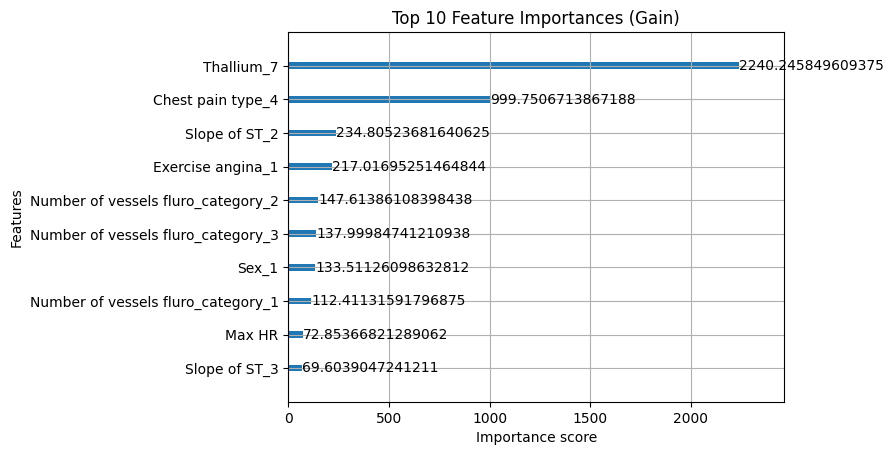

In [37]:
xgb.plot_importance(xgb_classifier, max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importances (Gain)")
plt.show()

## Test with XGBoost model

In [38]:
test_data = pd.read_csv('test.csv')
test_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [39]:
for col in categorical_variables:
    test_data[col] = test_data[col].astype('category')

test_data[f"Number of vessels fluro_category"] = test_data[f"Number of vessels fluro"].astype('category')

In [40]:


test_cat_data = ohc_cat.transform(test_data[categorical_variables + [f"Number of vessels fluro_category"]])
test_data_for_ml = pd.concat([
    test_data[req_num_columns],
    pd.DataFrame(ohc_cat.transform(test_data[categorical_variables + [f"Number of vessels fluro_category"]]), columns=ohc_cat.get_feature_names_out())
], axis=1)
test_data_for_ml = test_data_for_ml[stat_data_train.columns]
test_data_for_ml.head()

,Max HR,Age,Cholesterol,ST depression,Thallium_6,Number of vessels fluro_category_2,Number of vessels fluro_category_3,Sex_1,Slope of ST_3,Thallium_7,Number of vessels fluro_category_1,Chest pain type_3,Exercise angina_1,Slope of ST_2,EKG results_2,Chest pain type_2,Chest pain type_4
0,145,58,288,0.8,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
1,172,55,209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,150,54,268,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,168,44,177,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,163,43,267,1.8,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [41]:
test_pred_for_base_xgb = xgb_classifier.predict_proba(test_data_for_ml)[:, 1]
submission_df = pd.concat([test_data["id"], pd.Series(test_pred_for_base_xgb, name="Heart Disease")], axis=1)
submission_df.to_csv("xgb_submission.csv", index=False)

In [42]:
# import optuna
# import xgboost as xgb

# # 1. Setup the Pruner
# pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)
# study = optuna.create_study(direction='maximize', pruner=pruner)

# def objective(trial):
#     # Use DMatrix inside the objective to ensure GPU memory is cleared after each trial
#     dtrain = xgb.DMatrix(stat_data_train, label=y_train)
    
#     param = {
#         'tree_method': 'hist',
#         'device': 'cuda',
#         'objective': 'binary:logistic',
#         'eval_metric': 'auc',
#         'eta': trial.suggest_float('eta', 1e-2, 0.3, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 12), # 12 is safe for 8GB VRAM
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
#     }

#     # Use a callback for Optuna pruning
#     pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'test-auc')

#     cv_results = xgb.cv(
#         param,
#         dtrain,
#         num_boost_round=2000, # High limit, let early stopping/pruning handle it
#         nfold=5,
#         stratified=True,
#         early_stopping_rounds=50,
#         callbacks=[pruning_callback],
#         verbose_eval=False
#     )

#     return cv_results['test-auc-mean'].values[-1]

# study.optimize(objective, n_trials=100)

## Evaluating the performance of Random Forest with all features

In [43]:
rf_train_cat_columns = set(train_cat_data.columns) 
rf_num_vessels_cat = set([f"Number of vessels fluro_category_{i}" for i in range(1, 4)])
rf_train_num_columns = set(numerical_columns)
rf_num_vessels_num = set(["Number of vessels fluro"])


In [44]:
stat_data_cat_vessels = pd.concat([
    train_full_data[list(rf_train_num_columns - rf_num_vessels_num)],
    train_cat_data[list(rf_train_cat_columns)],
], axis=1)

X_train_cat_vessels, X_test_cat_vessels, y_train_cat_vessels, y_test_cat_vessels = train_test_split(
    stat_data_cat_vessels,
    train_full_data['y'],
    test_size=0.2,
    random_state=42
)

# scaler = StandardScaler()
# stat_data_cat_vessels_scaled = scaler.fit_transform(stat_data_cat_vessels)
rf_initial_classifier_cat = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_initial_classifier_cat.fit(X_train_cat_vessels, y_train_cat_vessels)
rf_initial_pred = rf_initial_classifier_cat.predict(X_test_cat_vessels)
print("Train Set Performance:")
print("Accuracy:", accuracy_score(y_train_cat_vessels, rf_initial_classifier_cat.predict(X_train_cat_vessels)))
print("Precision:", precision_score(y_train_cat_vessels, rf_initial_classifier_cat.predict(X_train_cat_vessels)))
print("Recall:", recall_score(y_train_cat_vessels, rf_initial_classifier_cat.predict(X_train_cat_vessels)))
print("F1 Score:", f1_score(y_train_cat_vessels, rf_initial_classifier_cat.predict(X_train_cat_vessels)))
print("ROC AUC Score:", roc_auc_score(y_train_cat_vessels, rf_initial_classifier_cat.predict_proba(X_train_cat_vessels)[:, 1]))
print()

print("Test Set Performance:")
print("Accuracy:", accuracy_score(y_test_cat_vessels, rf_initial_pred))
print("Precision:", precision_score(y_test_cat_vessels, rf_initial_pred))
print("Recall:", recall_score(y_test_cat_vessels, rf_initial_pred))
print("F1 Score:", f1_score(y_test_cat_vessels, rf_initial_pred))
print("ROC AUC Score:", roc_auc_score(y_test_cat_vessels, rf_initial_pred))




Train Set Performance:
Accuracy: 0.9999702380952381
Precision: 0.9999867261923198
Recall: 0.9999469068835225
F1 Score: 0.9999668161415137
ROC AUC Score: 0.9999999711120364

Test Set Performance:
Accuracy: 0.8796904761904762
Precision: 0.8705895027921926
Recall: 0.8590970302643702
F1 Score: 0.8648050870887476
ROC AUC Score: 0.8777472961108523


They are overfitting. So, it is important to tune.

In [ ]:
xgb_cat_classifier = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb_cat_classifier.fit(X_train_cat_vessels, y_train_cat_vessels)
xgb_cat_train_pred = xgb_cat_classifier.predict(X_train_cat_vessels)
xgb_cat_test_pred = xgb_cat_classifier.predict(X_test_cat_vessels)
xgb_explainer_shap = shap.TreeExplainer(xgb_cat_classifier)

print("Train Set Performance:")
print("Accuracy:", accuracy_score(y_train_cat_vessels, xgb_cat_train_pred))
print("Precision:", precision_score(y_train_cat_vessels, xgb_cat_train_pred))
print("Recall:", recall_score(y_train_cat_vessels, xgb_cat_train_pred))
print("F1 Score:", f1_score(y_train_cat_vessels, xgb_cat_train_pred))
print("ROC AUC Score:", roc_auc_score(y_train_cat_vessels, xgb_cat_classifier.predict_proba(X_train_cat_vessels)[:, 1]))
# print("Shap values calculated for training set:", xgb_explainer_shap.shap_values(X_train_cat_vessels))
shap_values_train_cat = xgb_explainer_shap.shap_values(X_train_cat_vessels)


print("Test Set Performance:")
print("Accuracy:", accuracy_score(y_test_cat_vessels, xgb_cat_test_pred))
print("Precision:", precision_score(y_test_cat_vessels, xgb_cat_test_pred))
print("Recall:", recall_score(y_test_cat_vessels, xgb_cat_test_pred))
print("F1 Score:", f1_score(y_test_cat_vessels, xgb_cat_test_pred))
print("ROC AUC Score:", roc_auc_score(y_test_cat_vessels, xgb_cat_classifier.predict_proba(X_test_cat_vessels)[:, 1]))
# print("Shap values calculated for test set:", xgb_explainer_shap.shap_values(X_test_cat_vessels))
shap_values_test_cat = xgb_explainer_shap.shap_values(X_test_cat_vessels)


Train Set Performance:
Accuracy: 0.8925416666666667
Precision: 0.8867649375492292
Recall: 0.8716872107531258
F1 Score: 0.879161432686365
ROC AUC Score: 0.9582331990067054
Test Set Performance:
Accuracy: 0.8867857142857143
Precision: 0.8797205064020602
Recall: 0.8655822524629669
F1 Score: 0.8725941142321261
ROC AUC Score: 0.954551270006659


In [ ]:
expected_value = xgb_explainer_shap.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    base_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
else:
    base_value = expected_value

shap_values_train_expl = shap.Explanation(
    values=shap_values_train_cat,
    base_values=np.repeat(base_value, shap_values_train_cat.shape[0]),
    data=X_train_cat_vessels,
    feature_names=X_train_cat_vessels.columns,
 )

shap.plots.beeswarm(shap_values_train_expl, show=False)
plt.title("What the model LEARNED (Train)")
plt.show()
print()

shap_values_test_expl = shap.Explanation(
    values=shap_values_test_cat,
    base_values=np.repeat(base_value, shap_values_test_cat.shape[0]),
    data=X_test_cat_vessels,
    feature_names=X_test_cat_vessels.columns,
 )

shap.plots.beeswarm(shap_values_test_expl, show=False)
plt.title("What the model LEARNED (Test)")
plt.show()

In [ ]:

rf_cat_explainer = shap.TreeExplainer(rf_initial_classifier_cat)
shap_values_cat = rf_cat_explainer.shap_values(X_test_cat_vessels)
shap.summary_plot(shap_values_cat, X_test_cat_vessels, plot_type="bar", max_display=10)

In [ ]:
stat_data_num_vessels = pd.concat([
    train_full_data[list(rf_train_num_columns)],
    train_cat_data[list(rf_train_cat_columns - rf_num_vessels_cat)],
], axis=1)

X_train_num_vessels, X_test_num_vessels, y_train_num_vessels, y_test_num_vessels = train_test_split(
    stat_data_num_vessels,
    train_full_data['y'],
    test_size=0.2,
    random_state=42
)


rf_initial_classifier_num = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_initial_classifier_num.fit(X_train_num_vessels, y_train_num_vessels)
rf_initial_pred = rf_initial_classifier_num.predict(X_test_num_vessels)
print("Accuracy:", accuracy_score(y_test_num_vessels, rf_initial_pred))
print("Precision:", precision_score(y_test_num_vessels, rf_initial_pred))
print("Recall:", recall_score(y_test_num_vessels, rf_initial_pred))
print("F1 Score:", f1_score(y_test_num_vessels, rf_initial_pred))
print("ROC AUC Score:", roc_auc_score(y_test_num_vessels, rf_initial_pred))

rf_num_explainer = shap.TreeExplainer(rf_initial_classifier_num)
shap_values_num = rf_num_explainer.shap_values(X_test_num_vessels)
shap.summary_plot(shap_values_num, X_test_num_vessels, plot_type="bar", max_display=10)